In [1]:
!pip install git+https://github.com/huggingface/transformers.git


  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-jizuk14d
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-jizuk14d
  Resolved https://github.com/huggingface/transformers.git to commit bb45d3631ec7026db04a77d33a52b31766372160
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.7 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-4.57.0.dev0-py3-none-any.whl size=12594930 sha256=90c3072ed2d7d38c1b28693da551d90a4ddfa4af08036e2a6f9f056882ca3f9c
  Stored in directory: /tmp/pip-ephem-wheel-cache-ddqos_w7/wheels/32/4b/78/f195c684dd3a9ed21f3b39fe8f85b48df7918581b6437be143
Successfully built transformers
  Attempting uninstall: huggingface-hub
    Found

In [2]:
!pip install accelerate safetensors


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 90.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 48.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [3]:
!nvidia-smi

Mon Sep  8 07:45:20 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       1MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os       
import random      
import textwrap   
import io        
import requests    
import numpy as np  

# Deep‑learning stack 
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import AutoProcessor, AutoModelForVision2Seq

import torch

# Imaging & visualisation
from PIL import Image                    
import matplotlib.pyplot as plt          
import matplotlib.patches as patches     

         

2025-09-08 07:45:39.887807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757317540.278187      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757317540.383932      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [5]:
import torch
from transformers import AutoProcessor, AutoTokenizer, AutoModelForVision2Seq

# Model ID
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

# Load processor and tokenizer
processor = AutoProcessor.from_pretrained(model_id)
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)

# Load model using device_map="auto" to split across 2 GPUs
model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    device_map="auto",       # Automatically splits model layers across GPUs
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True   # further reduces memory usage
)

# Check which devices the model layers are on
for name, param in model.named_parameters():
    if param.device.type == "cuda":
        print(name, param.device)
        break  # just print one as an example


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

model.visual.patch_embed.proj.weight cuda:0


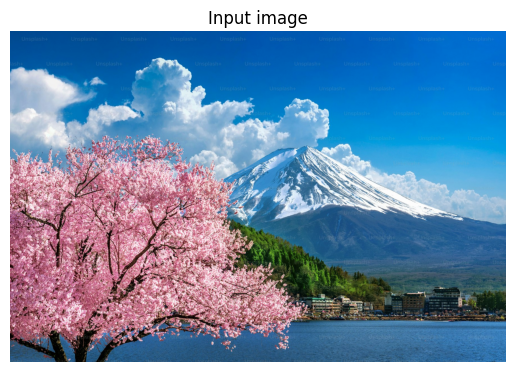

In [6]:
url = "https://plus.unsplash.com/premium_photo-1661964177687-57387c2cbd14?q=80&w=1770&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
img = Image.open(io.BytesIO(requests.get(url, timeout=15).content)).convert("RGB")

# Display the image
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()

In [7]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

In [8]:
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)



In [9]:
inputs = processor(text=text_prompt, images=img, return_tensors="pt").to(model.device)

# Generate
with torch.no_grad():
    outputs = model.generate(**inputs, max_new_tokens=1000)

print(processor.decode(outputs[0], skip_special_tokens=True))

system
You are a helpful assistant.
user
Describe this image.
assistant
The image depicts a stunning natural landscape featuring Mount Fuji, a prominent mountain in Japan. The mountain is covered with snow and has a distinctive conical shape. In the foreground, there is a large tree with vibrant pink blossoms, likely cherry blossoms, which are in full bloom. The tree is situated near a body of water, possibly a lake or river, which reflects the clear blue sky above. The sky is mostly clear with a few scattered clouds, adding to the serene and picturesque quality of the scene. In the background, there are buildings and structures, indicating that this location is near a populated area. The overall atmosphere of the image is tranquil and beautiful, capturing the essence of a peaceful day in a scenic Japanese setting.


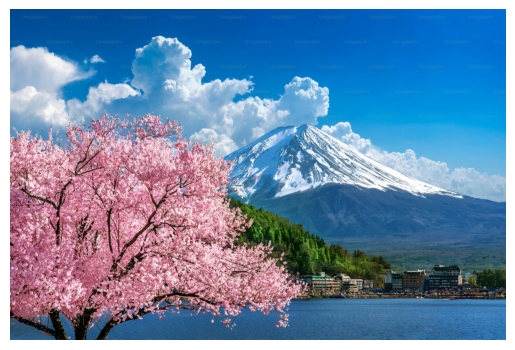

The image depicts a stunning natural landscape featuring Mount Fuji, a prominent
mountain in Japan. The mountain is covered with snow and has a distinctive
conical shape. In the foreground, there is a large tree with vibrant pink
blossoms, likely cherry blossoms, which are in full bloom. The tree is situated
near a body of water, possibly a lake or river, which reflects the clear blue
sky above. The sky is mostly clear with a few scattered clouds, adding to the
serene and picturesque quality of the scene. In the background, there are
buildings and structures, indicating that this location is near a populated
area. The overall atmosphere of the image is tranquil and beautiful, capturing
the essence of a peaceful day in a scenic Japanese setting.


In [10]:
# Extract the newly generated tokens (skip the prompt length)
caption = processor.batch_decode(
    outputs[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.figure()
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption

width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)